In [3]:
import pandas as pd
path = "../data/datasets/enhanced_student_habits_performance_dataset/enhanced_student_habits_performance_dataset.csv"
performance = pd.read_csv(path)
performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     80000 non-null  int64  
 1   age                            80000 non-null  int64  
 2   gender                         80000 non-null  object 
 3   major                          80000 non-null  object 
 4   study_hours_per_day            80000 non-null  float64
 5   social_media_hours             80000 non-null  float64
 6   netflix_hours                  80000 non-null  float64
 7   part_time_job                  80000 non-null  object 
 8   attendance_percentage          80000 non-null  float64
 9   sleep_hours                    80000 non-null  float64
 10  diet_quality                   80000 non-null  object 
 11  exercise_frequency             80000 non-null  int64  
 12  parental_education_level       80000 non-null 

In [4]:
performance.head()

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,...,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,...,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,...,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,...,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,...,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,...,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


In [5]:
performance.describe()

,student_id,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,previous_gpa,semester,stress_level,social_activity,screen_time,parental_support_level,motivation_level,exam_anxiety_score,time_management_score,exam_score
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,139999.500000,22.004288,4.174388,2.501366,1.997754,69.967884,7.017418,3.516587,6.804108,3.602448,4.497338,5.012478,2.500225,9.673029,5.479438,5.488525,8.508475,5.499132,89.141350
std,23094.155105,3.745570,2.004135,1.445441,1.155992,17.333015,1.467377,2.291575,1.921579,0.462876,2.295312,1.953174,1.704292,2.780869,2.873327,2.867782,1.796411,2.603534,11.591497
min,100000.000000,16.000000,0.000000,0.000000,0.000000,40.000000,4.000000,0.000000,1.000000,1.640000,1.000000,1.000000,0.000000,0.300000,1.000000,1.000000,5.000000,1.000000,36.000000
25%,119999.750000,19.000000,2.800000,1.200000,1.000000,55.000000,6.000000,2.000000,5.500000,3.270000,2.000000,3.600000,1.000000,7.800000,3.000000,3.000000,7.000000,3.200000,82.000000
50%,139999.500000,22.000000,4.125624,2.500000,2.000000,69.900000,7.000000,4.000000,6.900000,3.790000,5.000000,5.000000,2.000000,9.700000,5.000000,5.000000,10.000000,5.500000,93.000000
75%,159999.250000,25.000000,5.500000,3.800000,3.000000,84.900000,8.000000,6.000000,8.200000,4.000000,7.000000,6.400000,4.000000,11.600000,8.000000,8.000000,10.000000,7.800000,100.000000
max,179999.000000,28.000000,12.000000,5.000000,4.000000,100.000000,12.000000,7.000000,10.000000,4.000000,8.000000,10.000000,5.000000,21.000000,10.000000,10.000000,10.000000,10.000000,100.000000


## Note to self:.
Prepare a pipeline for the transformation that will happen to the data

In [6]:
def check_proportions(train, test, stratum):
    print("train,", train[stratum].value_counts() / len(train))
    print("Test,", test[stratum].value_counts() / len(test))

In [7]:
from sklearn.model_selection import StratifiedShuffleSplit

# Custom strata for major and gender
# Create the combined strata column
performance["strata_group"] = (
    performance["major"].astype(str) + "_" + performance["gender"].astype(str)
)

# Splitting the data
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(performance, performance["strata_group"]):
    strat_train_set = performance.loc[train_index]
    strat_test_set = performance.loc[test_index]

# Remove the strata_group coulmn 
performance.drop('strata_group', axis = 1, inplace = True)
strat_test_set.drop("strata_group", axis = 1, inplace = True)
strat_train_set.drop("strata_group", axis = 1, inplace = True)

# Remove the label from the test and training sets
# And making copy of the training data with the label for exploration
performance_df = strat_train_set.copy()  
performance_df_backup = strat_train_set.copy() 
strat_train_label = strat_train_set["exam_score"]
strat_train_set.drop("exam_score", axis = 1, inplace = True)    
strat_test_label = strat_test_set["exam_score"]
strat_test_set.drop("exam_score", axis = 1, inplace = True)    

  

In [8]:
strata = ["major", "gender"]
check_proportions(strat_train_set, strat_test_set, strata)

train, major             gender
Arts              Female    0.057422
Psychology        Male      0.057188
Computer Science  Male      0.056594
Business          Female    0.056563
Arts              Other     0.056297
Computer Science  Other     0.056094
Psychology        Female    0.055672
Engineering       Other     0.055234
Biology           Other     0.055219
Engineering       Female    0.055219
Psychology        Other     0.055094
Arts              Male      0.055094
Biology           Male      0.055078
Engineering       Male      0.054906
Business          Male      0.054875
Biology           Female    0.054719
Business          Other     0.054516
Computer Science  Female    0.054219
Name: count, dtype: float64
Test, major             gender
Arts              Female    0.057438
Psychology        Male      0.057188
Computer Science  Male      0.056563
Business          Female    0.056563
Arts              Other     0.056313
Computer Science  Other     0.056125
Psychology        Fem

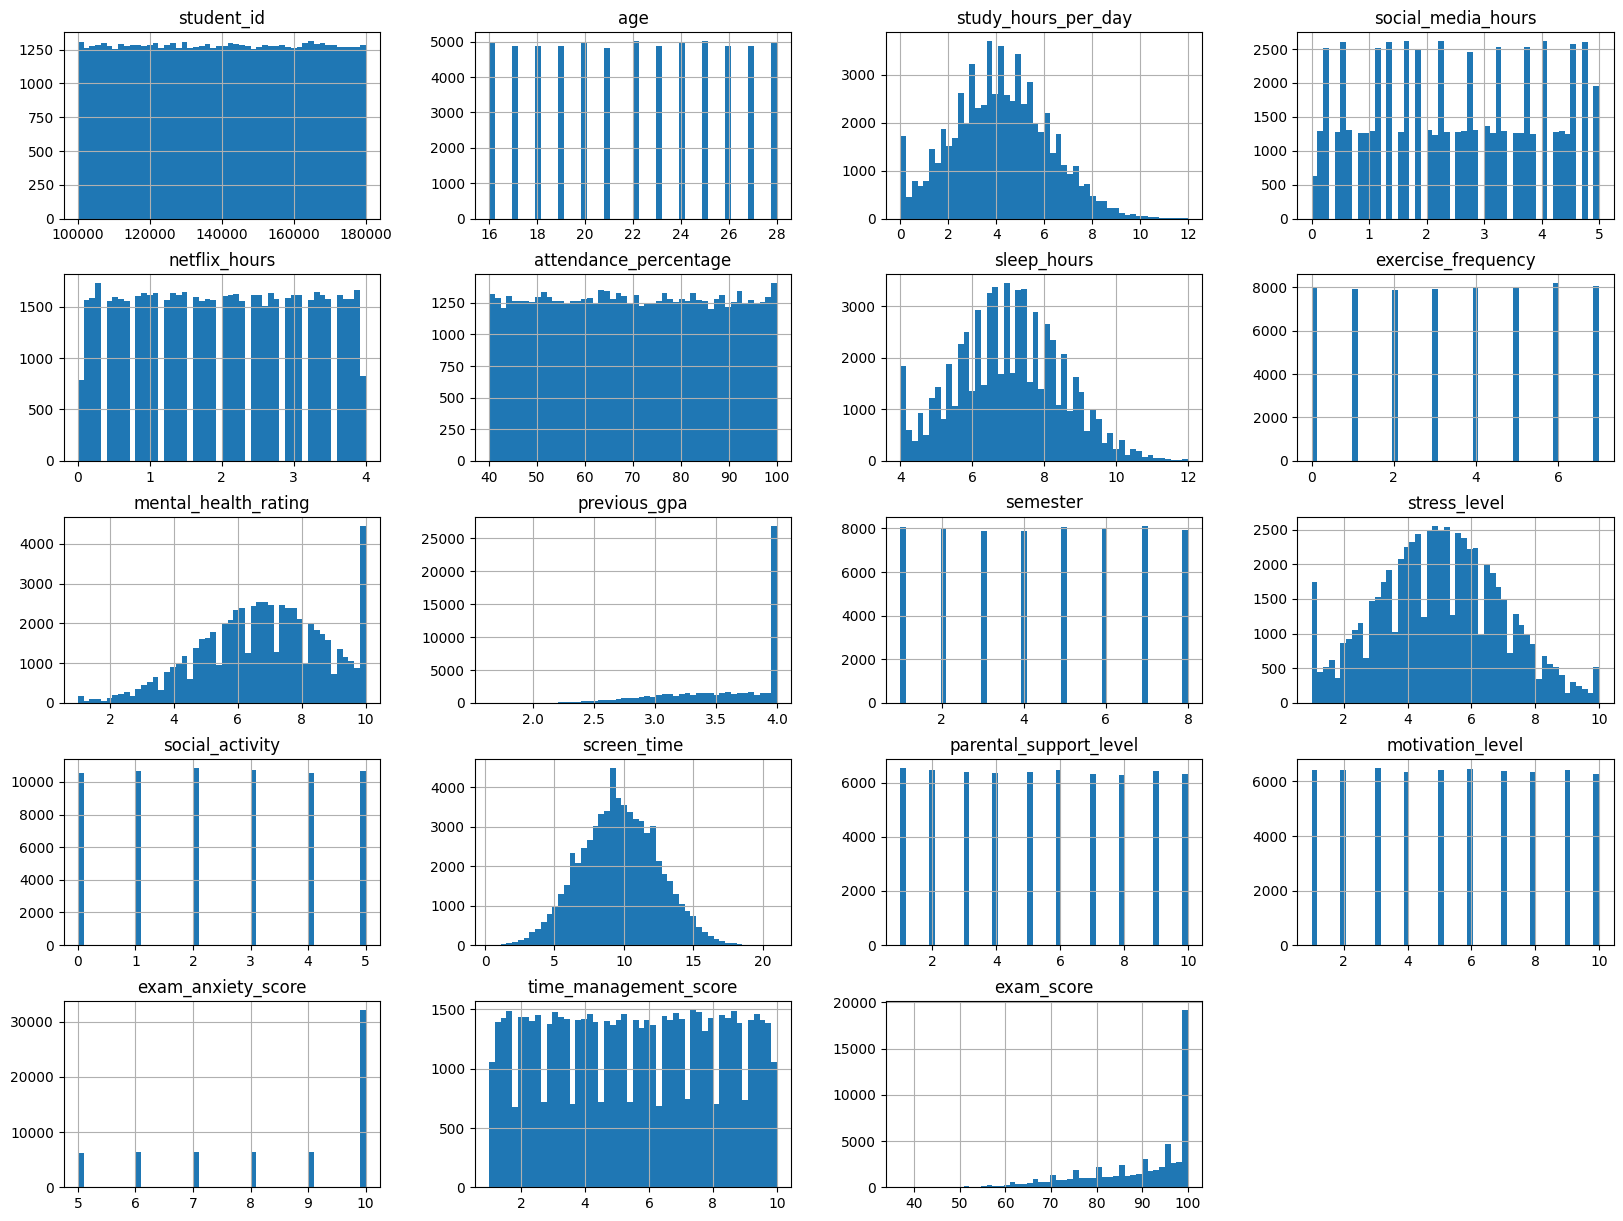

In [9]:
import matplotlib.pyplot as plt
performance_df.hist(bins=50, figsize=(20,15))
plt.show()

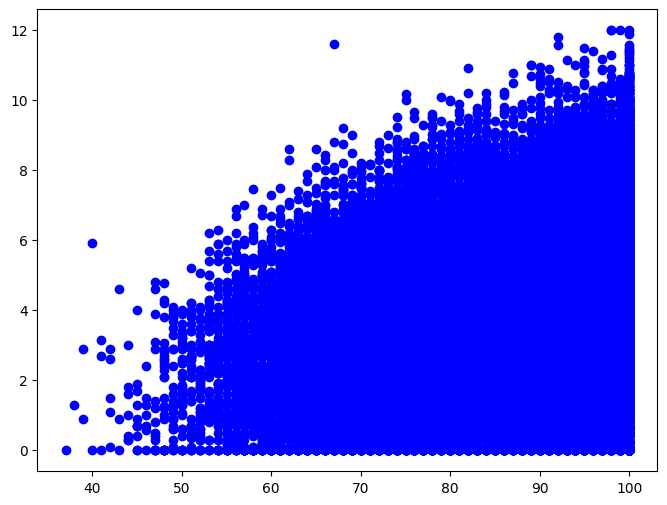

In [10]:
correlation = performance_df["exam_score"].corr(performance_df["study_hours_per_day"])
plt.figure(figsize=(8, 6))
plt.scatter(performance_df["exam_score"], performance_df["study_hours_per_day"], color='blue', label=f'Correlation: r={correlation:.2f}')

In [11]:
performance_df.select_dtypes('object')

,gender,major,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation,dropout_risk,study_environment,access_to_tutoring,family_income_range,learning_style
62077,Other,Psychology,Yes,Good,High School,Low,No,No,Quiet Room,No,Medium,Reading
15549,Female,Engineering,No,Good,Some College,Medium,Yes,No,Co-Learning Group,Yes,Medium,Reading
71981,Male,Psychology,Yes,Good,Some College,Low,Yes,No,Co-Learning Group,Yes,High,Kinesthetic
37463,Female,Computer Science,No,Poor,Some College,High,No,No,Cafe,Yes,Medium,Auditory
53237,Male,Computer Science,No,Good,Some College,Medium,No,No,Co-Learning Group,No,Low,Visual
...,...,...,...,...,...,...,...,...,...,...,...,...
49514,Other,Biology,Yes,Fair,Master,Medium,No,No,Cafe,Yes,Low,Kinesthetic
56238,Male,Arts,Yes,Good,Master,Medium,Yes,No,Library,Yes,Low,Auditory
16556,Other,Computer Science,Yes,Poor,Master,Low,No,No,Co-Learning Group,Yes,Low,Auditory
4951,Male,Biology,No,Fair,PhD,Medium,No,No,Cafe,No,Medium,Visual


In [12]:
corr_matrix = performance_d.corr()
corr_matrix["exam_score"].sort_values(ascending=False)

ValueError: could not convert string to float: 'Other'

In [ ]:
from pandas.plotting import scatter_matrix

attributes = ["exam_score", "previous_gpa", "motivation_level", 
              "study_hours_per_day", "access_to_tutoring", 
              "exam_anxiety_score", "stress_level"]

# Pass the dataframe subset directly
scatter_matrix(performance_df[attributes], figsize=(15, 12), alpha = 0.1)

In [ ]:
performance_df.plot(kind= 'scatter', x ='exam_score' ,y= 'previous_gpa', alpha = 0.7)

In [ ]:
strat_train_set["internet_quality"].head(20)

In [13]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

# Ordinal columns encoding
diet_quality = ['Poor', 'Fair', 'Good']
parental_education_level = ['High School','Some College','Bachelor','Master','PhD']
internet_quality = ['Low', 'Medium', 'High']
family_income_range = ['Low', 'Medium', 'High']
binary_order = ['No', 'Yes']

binary_columns = ['part_time_job', 'extracurricular_participation', 'dropout_risk', 'access_to_tutoring']
ordinal_columns = ['diet_quality', 'parental_education_level', 'internet_quality','family_income_range'] + binary_columns

# The categories in order 
columns_categories_order = [diet_quality,
                 parental_education_level,
                 internet_quality,
                 family_income_range] + [binary_order] * len(binary_columns)

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, categories = columns_categories_order)
performance_df[ordinal_coulmns] =encoder.fit_transform(performance_df[ordinal_columns])

# One Hot Encoding for nominal columns
nominal_columns = ['major', 'learning_style', 'gender', 'study_environment']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_array = ohe.fit_transform(performance_df[nominal_columns])

NameError: name 'ordinal_coulmns' is not defined

## Preprocess pipeline

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Categories and columns list
diet_quality = ['Poor', 'Fair', 'Good']
parental_education_level = ['High School','Some College','Bachelor','Master','PhD']
internet_quality = ['Low', 'Medium', 'High']
family_income_range = ['Low', 'Medium', 'High']
binary_order = ['No', 'Yes']

binary_columns = ['part_time_job', 'extracurricular_participation', 'dropout_risk', 'access_to_tutoring']
ordinal_columns = ['diet_quality', 'parental_education_level', 'internet_quality','family_income_range'] + binary_columns
nominal_columns = ['major', 'learning_style', 'gender', 'study_environment']

# Order for ordinal encoding
columns_categories_order = [diet_quality,
                 parental_education_level,
                 internet_quality,
                 family_income_range] + [binary_order] * len(binary_columns)

# Create the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(
            categories=columns_categories_order,
            handle_unknown='use_encoded_value', 
            unknown_value=-1
        ), ordinal_columns),
        
        ('nom', OneHotEncoder(
            drop='first',
            handle_unknown='ignore', 
            sparse_output=False
        ), nominal_columns)
    ],
    remainder='passthrough' # Keeps columns not specified (like numerical ones)
)



## The full pipeline

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()), 
    ('regressor', XGBRegressor(n_estimators=100, learning_rate=0.1))
])

# Model training 

In [33]:
full_pipeline.fit(strat_train_set, strat_train_label)
print(f"Random Forest R2: {full_pipeline.score(strat_test_set, strat_test_label):.4f}")

Random Forest R2: 0.8672


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 2. Make predictions on the test set
y_pred = full_pipeline.predict(strat_train_set)

# 3. Calculate Metrics
mae = mean_absolute_error(strat_train_label, y_pred)
mse = mean_squared_error(strat_train_label, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(strat_train_label, y_pred)

print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

R-squared: 0.8706
Mean Absolute Error: 3.20
Root Mean Squared Error: 4.17


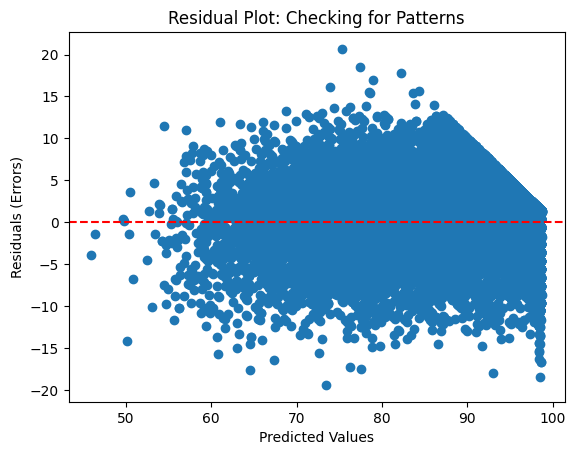

In [22]:
import matplotlib.pyplot as plt

residuals = strat_test_label - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot: Checking for Patterns')
plt.show()

In [27]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(full_pipeline, strat_train_set, strat_train_label, cv=5, scoring='r2')

print(f"All CV R2 scores: {cv_scores}")
print(f"Mean CV R2: {cv_scores.mean():.4f}")

All CV R2 scores: [0.87031219 0.86926848 0.87080574 0.87299394 0.86887902]
Mean CV R2: 0.8705
